In [1]:
import copy
import snappy
import khovanov
import itertools
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from knot_graphs import *
from geography import *

## Approach: do band moves entirely within kh package
### ~~TODO - write `writhe` function for `khovanov.Link`~~
### ~~TODO - write `normal_euler_number` function for `khovanov.Cobordism`~~
### Question: is it the case that $e(F) = - e(F')$ where $F'$ is the surface obtained by mirroring the knots on either end?
### ~~TODO - plot $e(F)$ vs $b_1(F)$~~
### TODO (?) - plot Corollary 2.11 bound from Allen
$$
\left| \Upsilon_K(1) - \frac{\sigma(K)}{2} \right| \le \gamma_4(K)
$$
would give a horizontal line in the $e$-$b_1$ plane

In [2]:
def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    n = len([c for c in link.crossings if len(c.adjacent) == 4])
    if n_plus + n_minus != n:
        print('something went wrong!')
        print(f'link: {link}')
        print(f'n = {len(link.crossings)}, n+ = {n_plus}, n- = {n_minus}')
    writhe_ret = n_plus - n_minus
    return writhe_ret

In [3]:
def normal_euler_number(cob : khovanov.Cobordism, bands : list):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    total_twist = sum(twist for twist,_,_ in bands)
    writhe_orig = writhe(knot)
    writhe_prime = writhe(knot_prime)
    e = writhe_prime - writhe_orig - total_twist
    
    return e

In [4]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

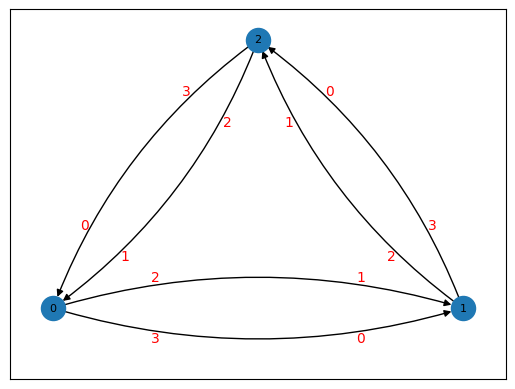

In [5]:
draw_adjacency_graph(K)

In [6]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (0,1))
print(normal_euler_number(cob, [(0,(0,0),(0,1))]))

6


### TODO - search for sequences of bands resulting in the unknot
1. Try a band
2. Attempt to simplify
3. If resulting knot is the unknot, we are done!
4. Otherwise, try another band.

WANT: list of band sequences taking $K$ to $\mathcal{U}$

Two approaches:
- Recursive search using depth tracking
- Iterative

In [7]:
def try_bands_helper(cob : khovanov.Cobordism, prev_bands : list, max_depth=5, return_cob=False):
    if len(prev_bands) == max_depth: return []

    # only get full Crossings, not CrossingStrands
    crossings = [c for c in cob.links[-1].crossings if len(c.adjacent) == 4]
    strands = [0,1,2,3]
    twists = [-1,0,1]
    #twists = [0]
    cs_pairs = itertools.product(crossings, strands)

    results = []
    for twist in twists:
        for (c0,s0) in cs_pairs:
            for (c1, s1) in cs_pairs:
                if c0 == c1 and s0 == s1: continue

                cob_copy = copy.deepcopy(cob)
                try:
                    cob_copy.band_move(twist, (c0,s0), (c1,s1))
                    cob_copy.finish()
                except:
                    # if simplification fails then ignore this band
                    continue

                new_bands = prev_bands + [(twist, (c0,s0), (c1,s1))]

                # check if unknot reached
                if cob_copy.movie[-1][0] == 'morse_death' and len(cob_copy.links[-1].crossings) == 0:
                    if return_cob:
                        results.append((new_bands, cob_copy))
                    else: 
                        results.append(new_bands)
                else:
                    # try other bands
                    results.extend(try_bands_helper(cob_copy, new_bands, max_depth, return_cob))
    return results

def try_bands(knot : khovanov.Link, max_depth=5, return_cob=False):
    cob = khovanov.Cobordism(knot)
    return try_bands_helper(cob, [], max_depth, return_cob=return_cob)

### Draw band sequence movies

In [8]:
# Example of a cobordism from 3_1 to the unknot U
S = khovanov.Cobordism(khovanov.Link(snappy.Link("3_1").PD_code()))
S.band_move(0, (1,3), (1,2))
S.finish()
print(S)
print(S.links)

('morse_saddle', [1-3, 1-2], 2-0)
('reidemeister_1', [1-2], (True, None))
('reidemeister_1', [0-2], (True, None))
('reidemeister_1', [2-0], (True, 2s))
('morse_death', [2s-0], None)

[Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)], Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (1, 3), (1, 2)]
2 [(2, 1), (2, 0), (0, 1), (0, 0)], Link of 2 crossings:
0 [(2, 3), (2, 2), (0, 3), (0, 2)]
2 [(2, 1), (2, 0), (0, 1), (0, 0)], Link of 1 crossing:
2 [(2, 1), (2, 0), (2, 3), (2, 2)], Link of 1 crossing:
2s [(2s, 1), (2s, 0)], Link of 0 crossings.]


In [9]:
def draw_movie(cob, band_seq):
  links = list(cob.links)
  n = len(links)
  band_idx = 0

  plt.figure(figsize=(5*n, 5))
  for i, link in enumerate(links):
    move = cob.movie[i-1]
    title = 'Original knot' if i == 0 else f'Result of: {move}'
    if move[0] == 'morse_saddle': # band applied
      title += f'\nBand: {band_seq[band_idx]}'
      band_idx += 1
    plt.subplot(1, n, i+1, title=title)

    # ignore the empty link
    if move[0] == 'morse_death' and len(link.crossings) == 0: continue
    try:
      snappy_link = snappy.Link(link.PD_code())
      draw_adjacency_graph(snappy_link)
    except:
      print(f'')
      continue
  plt.show()

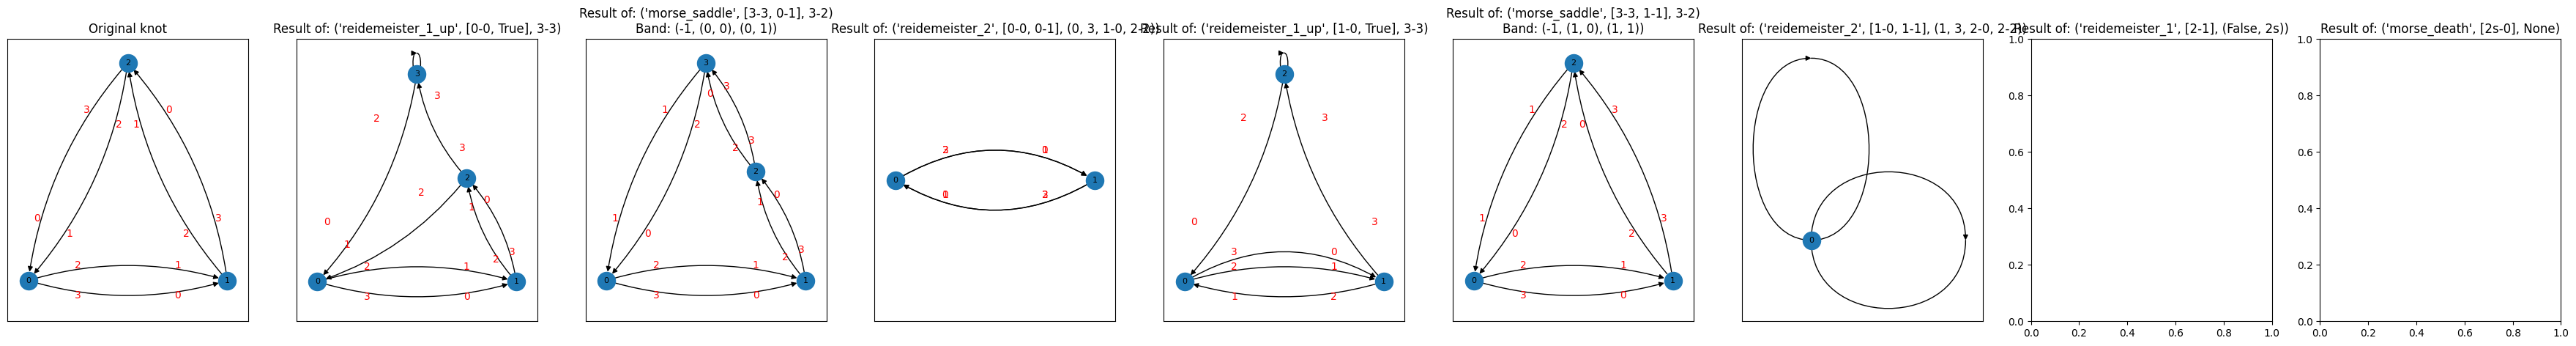

In [10]:
K = khovanov.Link(snappy.Link("3_1").PD_code())
band_seqs = try_bands(K, max_depth=3, return_cob=True)

bands, cob = band_seqs[0]
draw_movie(cob, bands)

In [ ]:
band_seqs

In [19]:
len(band_seqs)

22

In [22]:
S = khovanov.Cobordism(K)
S.band_move(-1, (0,0), (0,1))
S.finish()
S.band_move(-1, (2,0), (2,1))
S.finish()
print(S); print(S.links)

('reidemeister_1_up', [0-0, True], 3-3)
('morse_saddle', [3-3, 0-1], 3-2)
('reidemeister_2', [0-0, 0-1], (0, 3, 1-0, 2-2))
('reidemeister_1_up', [2-0, True], 3-3)
('morse_saddle', [3-3, 2-1], 3-2)
('reidemeister_2', [1-2, 1-3], (1, 3, 2-2, 2-0))
('reidemeister_1', [2-1], (False, 2s))
('morse_death', [2s-0], None)

[Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)], Link of 4 crossings:
0 [(3, 0), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (3, 1)]
3 [(0, 0), (2, 3), (3, 3), (3, 2)], Link of 4 crossings:
0 [(3, 0), (3, 3), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (3, 2), (3, 1)]
3 [(0, 0), (2, 3), (2, 2), (0, 1)], Link of 2 crossings:
1 [(2, 3), (2, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (1, 1), (1, 0)], Link of 3 crossings:
1 [(2, 3), (2, 2), (2, 1), (3, 1)]
2 [(3, 0), (1, 2), (1, 1), (1, 0)]
3 [(2, 0), (1, 3), (3, 3), (3, 2)], Link of 3 cro

#### Band move plotting on $e$-$b_1$ plane

In [23]:
def plot_bands_to_unknot(K_snappy : snappy.Link, max_depth=3,
                         erange=(-40,40), brange=(0,30), knot_name=None):
    if knot_name is None:
        knot_name = "?"
        
    fig, ax = plot_bounds(K_snappy, erange=erange, brange=brange,
                          plot_intersection=False)

    K_khov = khovanov.Link(K_snappy.PD_code())
    band_seqs = try_bands(K_khov, max_depth=max_depth, return_cob=True)

    es = [normal_euler_number(cob, bands) for bands, cob in band_seqs]
    bs = [len(seq) for seq,_ in band_seqs]

    for (seq,_),e,b in zip(band_seqs, es, bs):
        print(f'e={e}, b={b}: {seq}')

    ax.scatter(es, bs, c='red', s=6)
    ax.set_title(f'Possible planar bands on ' + knot_name)
                    
    return fig, ax

### Trefoil $3_1$

e=5, b=2: [(-1, (0, 0), (0, 1)), (-1, (1, 0), (1, 1))]
e=6, b=3: [(-1, (0, 0), (0, 1)), (-1, (1, 0), (1, 3)), (-1, (1, 0), (1, 1))]
e=6, b=3: [(-1, (0, 0), (0, 1)), (-1, (1, 0), (2, 1)), (-1, (1, 0), (1, 1))]
e=6, b=3: [(-1, (0, 0), (0, 1)), (-1, (1, 0), (2, 3)), (-1, (1, 0), (1, 1))]
e=6, b=3: [(-1, (0, 0), (0, 2)), (-1, (0, 0), (1, 1)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 1)), (-1, (1, 0), (1, 1))]
e=5, b=2: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (1, 1)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (1, 2)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (1, 3)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (2, 1)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0), (3, 0)), (-1, (0, 0), (0, 1))]
e=6, b=3: [(-1, (0, 0), (1, 1)), (-1, (0, 0

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

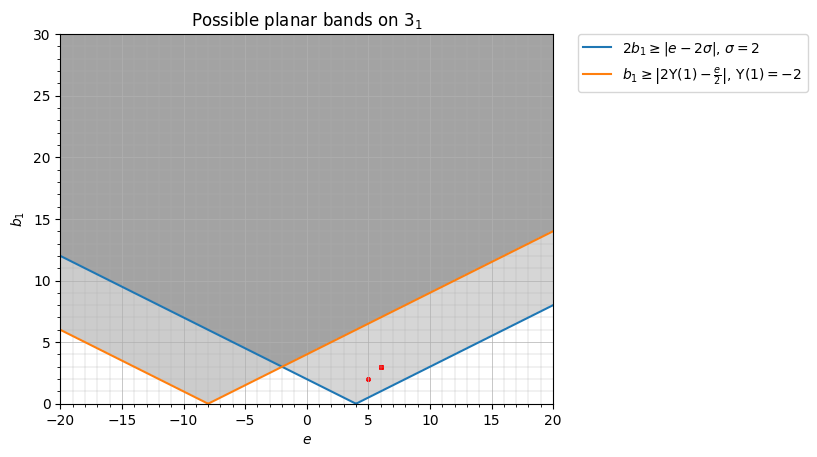

In [24]:
trefoil = snappy.Link('3_1')
plot_bands_to_unknot(trefoil, erange=(-20,20), knot_name='$3_1$')

### Mirrored trefoil $-3_1$

e=-2, b=1: [(-1, (0, 0), (0, 1))]
e=-1, b=2: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (1, 1)), (-1, (1, 0), (1, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (1, 1)), (-1, (1, 0), (1, 3))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (2, 2)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (2, 3)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (3, 0)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (0, 3)), (-1, (0, 0), (3, 1)), (-1, (0, 0), (0, 1))]
e=-2, b=1: [(-1, (0, 0), (1, 1))]
e=-1, b=2: [(-1, (0, 0), (1, 3)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (1, 3)), (-1, (0, 0), (0, 3)), (-1, (0, 0), (0, 1))]
e=0, b=3: [(-1, (0, 0), (1, 3)), (-1, (0, 0), (0, 3)), (-1, (0, 0), (1, 1))]
e=-1, b=2: [(-1, (0, 0), (1, 3)), (-1, (0, 0), (1, 1))]
e=0, b=3: [(-1, (0, 0), (1, 3)), (-1, (0, 0), (2, 1)), (-1, (1, 0), (1,

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $-3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

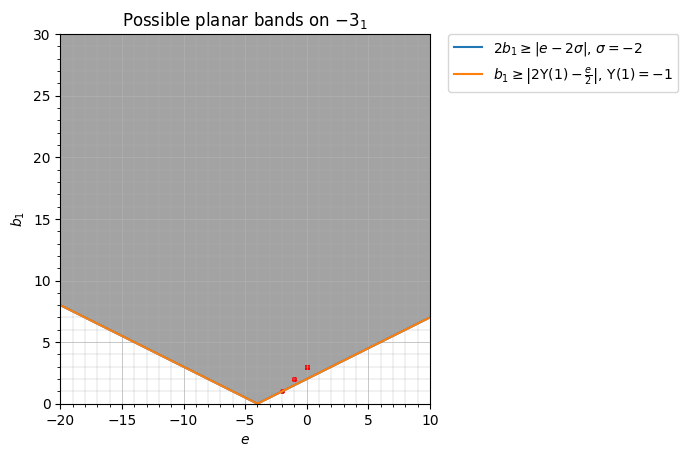

In [25]:
plot_bands_to_unknot(trefoil.mirror(), erange=(-20,10), knot_name='$-3_1$')

### Torus Knots $T(4,q)$

In [26]:
T45 = snappy.Link('T(4,5)')
T45_kh = khovanov.Link(T45.PD_code())

In [ ]:
plot_bands_to_unknot(T45, max_depth=2, erange=(-30,10), knot_name='T(4,5)')

In [28]:
T47 = snappy.Link('T(4,7)')
T47_kh = khovanov.Link(T45.PD_code())

In [ ]:
plot_bands_to_unknot(T47, max_depth=2, erange=(-30,10), knot_name='T(4,7)')

## ~~Approach - write band move function from scratch~~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [ ]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [ ]:
vars(dg)

In [ ]:
dg_nx = dg.to_networkx()

In [ ]:
dg_nx.nodes.data()

In [ ]:
dg_nx.edges

In [ ]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

In [ ]:
draw_dual_graph(K)

In [ ]:
draw_adjacency_graph(K)